In [1]:
import math
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

In [2]:
# Selecting the brain region
select_region = "Microglia"

In [3]:
# Loading AnnData object
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
expr_path = base_path / f"WMB-10Xv3-{select_region}-raw-wmeta.h5ad"
adata = sc.read_h5ad(expr_path)
adata

AnnData object with n_obs × n_vars = 81472 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color', 'batch'
    var: 'gene_symbol'

In [4]:
gene_names_df = adata.var.copy()
adata.var.set_index("gene_symbol", inplace=True)

**Differential Expression**

In [5]:
# Preprocess the data
sc.pp.normalize_total(adata, target_sum=1e4)  # Normalize counts per cell
sc.pp.log1p(adata)  # Log-transform the data
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=True)  # Select highly variable genes
sc.tl.pca(adata)
sc.pp.neighbors(adata, n_neighbors=15)
adata.obsm["X_umap"] = adata.obs[["x", "y"]].to_numpy()

/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# Clustering the data
resolution_list = [0.1, 0.5, 1.0, 3]
for res in resolution_list:
    sc.tl.leiden(
        adata,
        resolution=res,
        flavor="igraph",
        n_iterations=2,
        key_added=f"leiden_res_{res:4.2f}"
        )

In [7]:
# Selecting the leiden key
leiden_key = "leiden_res_0.50"

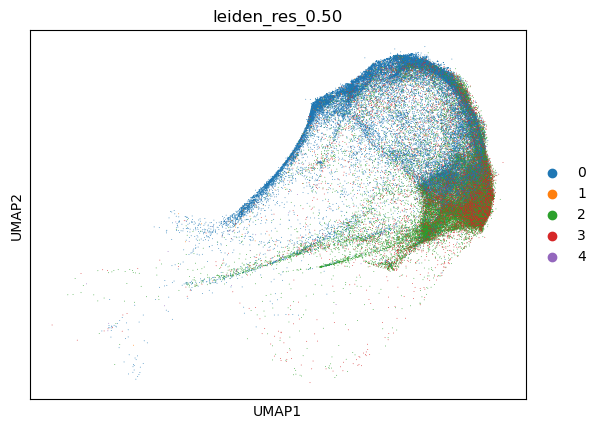

In [8]:
sc.pl.umap(adata, color=leiden_key)

In [9]:
# Perform differential expression analysis
sc.tl.rank_genes_groups(
    adata,
    groupby=leiden_key,
    method="wilcoxon",
    use_raw=False
)

In [10]:
# Extract the differential expression results
deg_results = pd.DataFrame({
    group: pd.DataFrame(adata.uns["rank_genes_groups"]["names"])[group]
    for group in adata.uns["rank_genes_groups"]["names"].dtype.names
})

# Save the dataframe to a CSV file
output_path = base_path / "outputs/DEG/" / f"WMB-10Xv3-{select_region}-DEG-{leiden_key}.csv"
deg_results.to_csv(output_path, index=False)

print(f"Differentially expressed genes saved to {output_path}")

Differentially expressed genes saved to /data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs/DEG/WMB-10Xv3-Microglia-DEG-leiden_res_0.50.csv


## Visualization

In [11]:
deg_results.head()

,0,1,2,3,4
0,Egr1,Gm34455,Uty,Xist,Ccl4
1,Nfkbia,Polg2,Nrgn,Hist1h2bc,Csf1
2,Nfkbiz,Gadd45g,Camk2n1,Csmd3,Ccl3
3,Ier2,Chka,Ddx3y,Hist1h1d,Slc15a3
4,Tnfaip3,Milr1,Camk2a,Hist1h1c,Myo1e


### UMAP: expression of top DEGs in one cluster

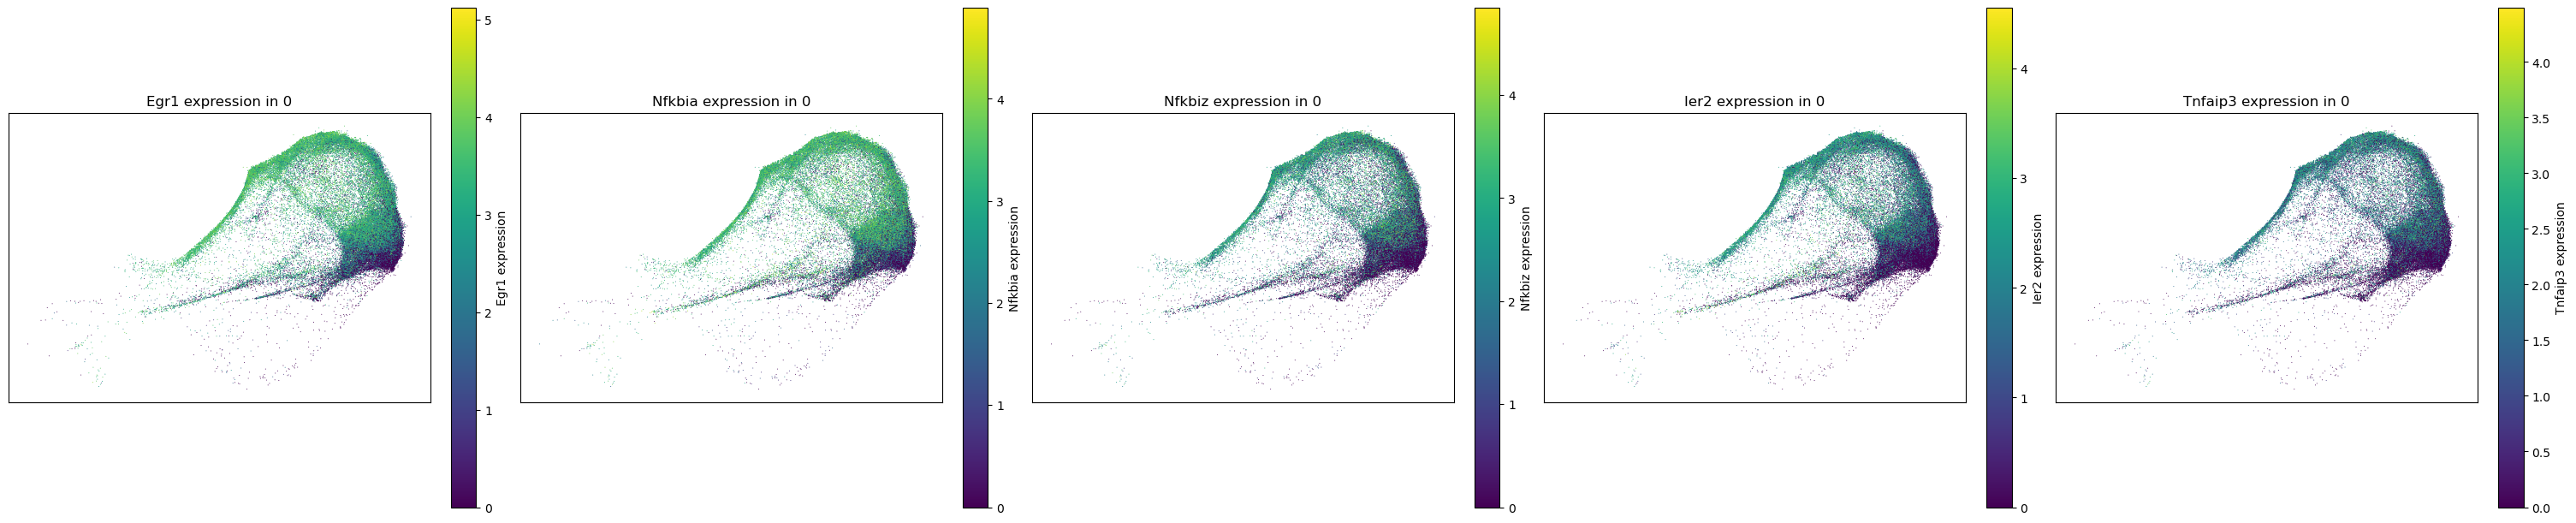

In [20]:
# Select a group and get the top 5 genes
group = "0"
top_genes = deg_results[group].head(5)

# Create a figure with subplots
fig, axes = plt.subplots(1, len(top_genes), figsize=(6 * len(top_genes), 6), constrained_layout=True)

# If there's only one gene, make sure axes is iterable
if len(top_genes) == 1:
    axes = [axes]

# Plot the expression of each gene using UMAP coordinates from adata.obs
for ax, gene in zip(axes, top_genes):
    scatter = ax.scatter(
        adata.obs["x"],
        adata.obs["y"],
        c=adata[:, gene].X.toarray().flatten(),
        cmap="viridis",
        s=0.5,
        edgecolor="none"
    )
    fig.colorbar(scatter, ax=ax, label=f"{gene} expression")
    ax.set_title(f"{gene} expression in {group}")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

plt.show()

### Heatmap: expression of top DEGs across clusters - cluster level

In [21]:
def plot_top_deg_expression_heatmap(adata, deg_results, group_by, n_top_genes=1, agg_func="median"):
    """
    Plot a heatmap of aggregated expression values (mean or median) of top DEGs across clusters.

    Parameters:
    - adata: AnnData object
    - deg_results: DataFrame where each column corresponds to a cluster and contains ranked DEG gene names
    - group_by: Column in adata.obs used to group cells (e.g., "leiden", "louvain")
    - n_top_genes: Number of top genes to include per cluster
    - agg_func: Aggregation function to use, either "median" or "mean"
    """
    if agg_func not in ["median", "mean"]:
        raise ValueError("agg_func must be 'median' or 'mean'")

    # Extract top genes per cluster
    top_deg_genes = []
    gene_cluster_mapping = {}
    for cluster in deg_results.columns:
        cluster_top_genes = deg_results[cluster].dropna().head(n_top_genes).tolist()
        top_deg_genes.extend(cluster_top_genes)
        for gene in cluster_top_genes:
            gene_cluster_mapping[gene] = cluster

    top_deg_genes = list(set(top_deg_genes))  # Remove duplicates

    # Aggregate expression by group
    expression_df = adata[:, top_deg_genes].to_df()
    grouped = expression_df.groupby(adata.obs[group_by])

    if agg_func == "mean":
        aggregated_expression = grouped.mean()
    else:  # median
        aggregated_expression = grouped.median()

    # Maintain cluster order if categorical
    if hasattr(adata.obs[group_by], "cat"):
        cluster_order = adata.obs[group_by].cat.categories
        aggregated_expression = aggregated_expression.loc[cluster_order]
    else:
        cluster_order = aggregated_expression.index.tolist()

    # Order genes based on their original cluster association
    ordered_genes = []
    for cluster in cluster_order:
        cluster_genes = [gene for gene in top_deg_genes if gene_cluster_mapping.get(gene) == cluster]
        ordered_genes.extend(cluster_genes)
    
    aggregated_expression = aggregated_expression[ordered_genes]

    # Plot heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        aggregated_expression.T,
        cmap="viridis",
        cbar_kws={"label": f"{agg_func.capitalize()} Expression"},
        xticklabels=True,
        yticklabels=ordered_genes
    )
    plt.xlabel("Clusters")
    plt.ylabel("Genes")
    plt.title(f"{agg_func.capitalize()} Expression of Top {n_top_genes} DEGs per Cluster")
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_44912/3894149361.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = expression_df.groupby(adata.obs[group_by])


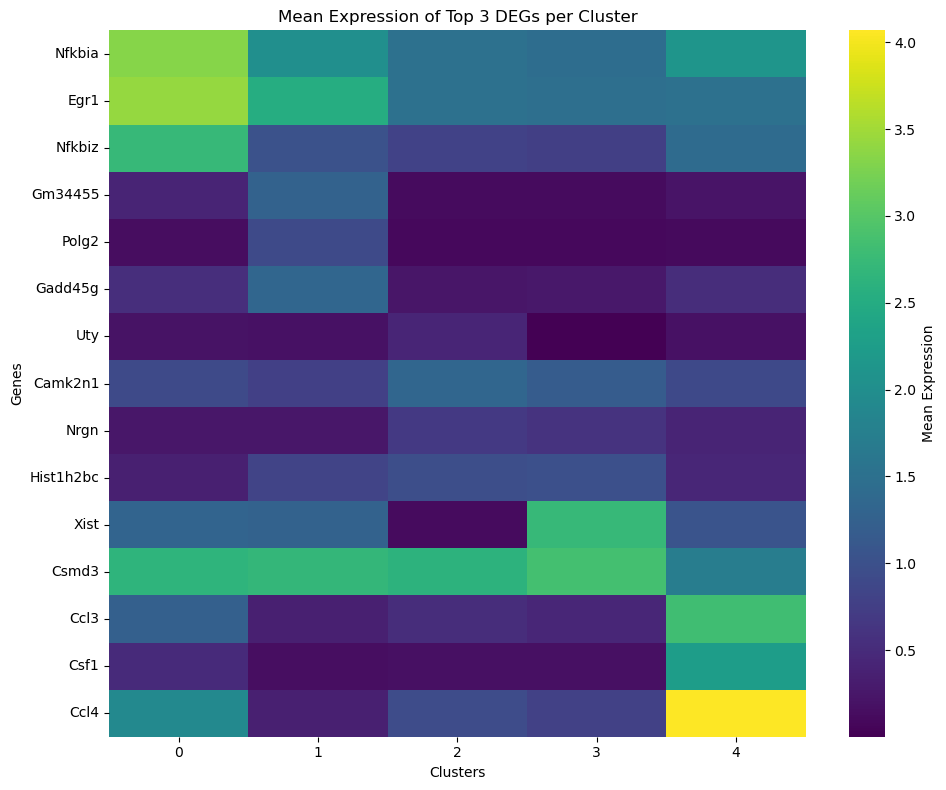

In [23]:
plot_top_deg_expression_heatmap(
    adata=adata,
    deg_results=deg_results,
    group_by=leiden_key,
    n_top_genes=3,
    agg_func="mean"
)

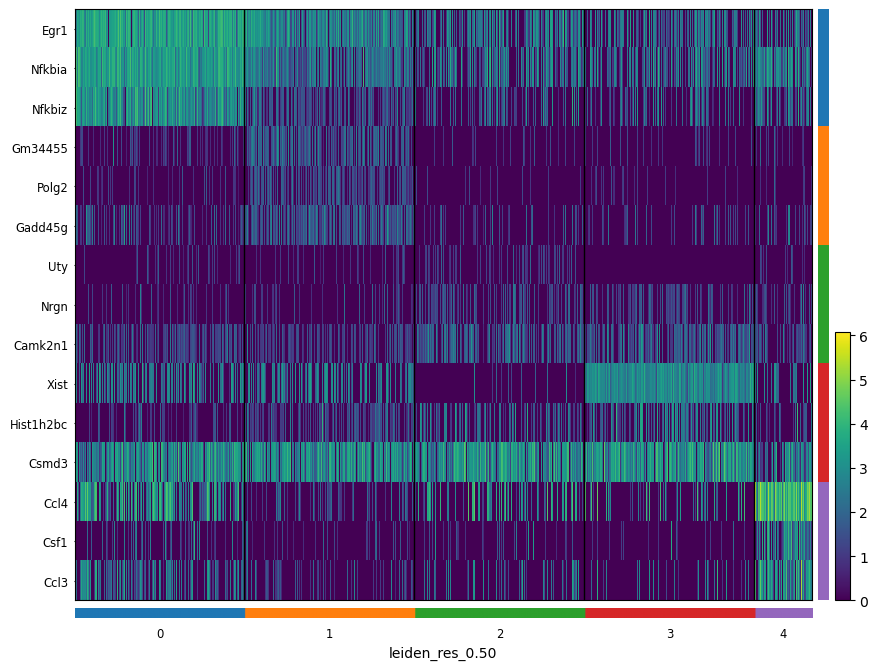

In [24]:
# Define the number of top genes to include per group
n_top_genes = 3
group_by = leiden_key  # Use the leiden clustering as the grouping variable

# Extract the top genes for all groups and separate them by group
top_genes_for_heatmap = []
var_group_positions = []
var_group_labels = []
start_idx = 0

for group in deg_results.columns:
    if not deg_results[group].empty:
        group_genes = deg_results[group].dropna().head(n_top_genes).tolist()
        if group_genes:  # Ensure the group has genes
            top_genes_for_heatmap.extend(group_genes)
            var_group_positions.append((start_idx, start_idx + len(group_genes) - 1))
            var_group_labels.append(group)
            start_idx += len(group_genes)

# Compute group sizes
group_sizes = adata.obs[group_by].value_counts()

# Compute scaling factors (normalize based on the largest group)
max_group_size = group_sizes.max() if len(group_sizes) > 0 else 1
scaling_factors = group_sizes / max_group_size  # This replicates your previous calculation

# Store the scaling factors in the AnnData object
adata.obs["scaled_group"] = adata.obs[group_by].map(scaling_factors)

# Downsample cells in large groups to balance the heatmap
max_cells_per_group = 500  # Set a maximum number of cells to display per group

downsampled_indices = []
for group, size in group_sizes.items():
    group_indices = adata.obs[adata.obs[group_by] == group].index.to_list()
    if size > max_cells_per_group:
        sampled_indices = np.random.choice(group_indices, max_cells_per_group, replace=False)
        downsampled_indices.extend(sampled_indices)
    else:
        downsampled_indices.extend(group_indices)

# Ensure correct indexing before subsetting
adata_downsampled = adata[downsampled_indices].copy()

# Adjust the figure size dynamically based on the number of groups and genes
fig_width = max(10, len(var_group_labels) * 2)  # Minimum width of 10, scale with groups
fig_height = max(8, len(top_genes_for_heatmap) * 0.2)  # Minimum height of 8, scale with genes

# Ensure there are genes before plotting
if top_genes_for_heatmap:
    sc.pl.heatmap(
        adata_downsampled,
        var_names=top_genes_for_heatmap,
        groupby=group_by,
        cmap="viridis",
        swap_axes=True,
        figsize=(fig_width, fig_height),
        dendrogram=False,
        var_group_positions=var_group_positions,
        var_group_labels=var_group_labels,
        show=True
    )
else:
    print("No genes selected for the heatmap.")


## Modules

In [25]:
# Loading Module Eigengenes dataframe
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs")
modules_df = pd.read_csv(base_path / f"WMB-10Xv3-{select_region}-raw-mc-wgcna-modules.csv", index_col="Unnamed: 0")
modules_df.head()

,gene_name,module,color,kME_MG-M1,kME_grey,kME_MG-M2,kME_MG-M3,kME_MG-M4,kME_MG-M5
ENSMUSG00000004296,ENSMUSG00000004296,MG-M1,turquoise,0.067324,-0.005248,0.069128,-0.008137,0.007815,-0.031117
ENSMUSG00000002985,ENSMUSG00000002985,MG-M1,turquoise,0.189944,0.147565,0.190743,0.233783,0.050853,-0.158240
ENSMUSG00000039109,ENSMUSG00000039109,grey,grey,0.001604,0.012000,0.142080,0.001089,0.063053,0.013650
ENSMUSG00000015568,ENSMUSG00000015568,MG-M2,brown,0.067394,0.009954,0.541998,-0.002288,0.017932,-0.027402
ENSMUSG00000020914,ENSMUSG00000020914,grey,grey,0.018736,-0.008138,0.052446,-0.005465,0.032833,0.016444


In [26]:
n_top_genes_per_module = 3  # Set the number of top genes to select per module

# Create an empty list to store dataframes for each module
top_genes_by_module = []

# Iterate through each unique module in the "module" column
for module_name in modules_df["module"].unique():
    if module_name == "grey":
        continue  # Skip the grey module
    
    # Filter the dataframe for the current module
    module_genes = modules_df[modules_df["module"] == module_name]
    
    # Sort the genes by the corresponding kME column in descending order
    sorted_genes = module_genes.sort_values(by=f"kME_{module_name}", ascending=False)
    
    # Select the top genes (you can adjust the number of top genes as needed)
    top_genes = sorted_genes.head(n_top_genes_per_module)
    
    # Append the top genes dataframe to the list
    top_genes_by_module.append(top_genes)

# Combine all the top genes dataframes into a single dataframe
top_genes_df = pd.concat(top_genes_by_module, ignore_index=True)

# Display the resulting dataframe
top_genes_df.head()

,gene_name,module,color,kME_MG-M1,kME_grey,kME_MG-M2,kME_MG-M3,kME_MG-M4,kME_MG-M5
0,ENSMUSG00000038418,MG-M1,turquoise,0.772310,0.063035,0.054245,-0.034519,-0.026892,-0.348611
1,ENSMUSG00000021025,MG-M1,turquoise,0.747866,0.002690,0.069530,-0.046087,-0.013457,-0.313880
2,ENSMUSG00000035356,MG-M1,turquoise,0.732437,0.023227,0.095436,-0.033552,-0.004144,-0.288948
3,ENSMUSG00000015568,MG-M2,brown,0.067394,0.009954,0.541998,-0.002288,0.017932,-0.027402
4,ENSMUSG00000112148,MG-M2,brown,0.119674,0.019395,0.517916,-0.001351,0.030454,-0.055215


### Heatmap: kME of hub genes across modules

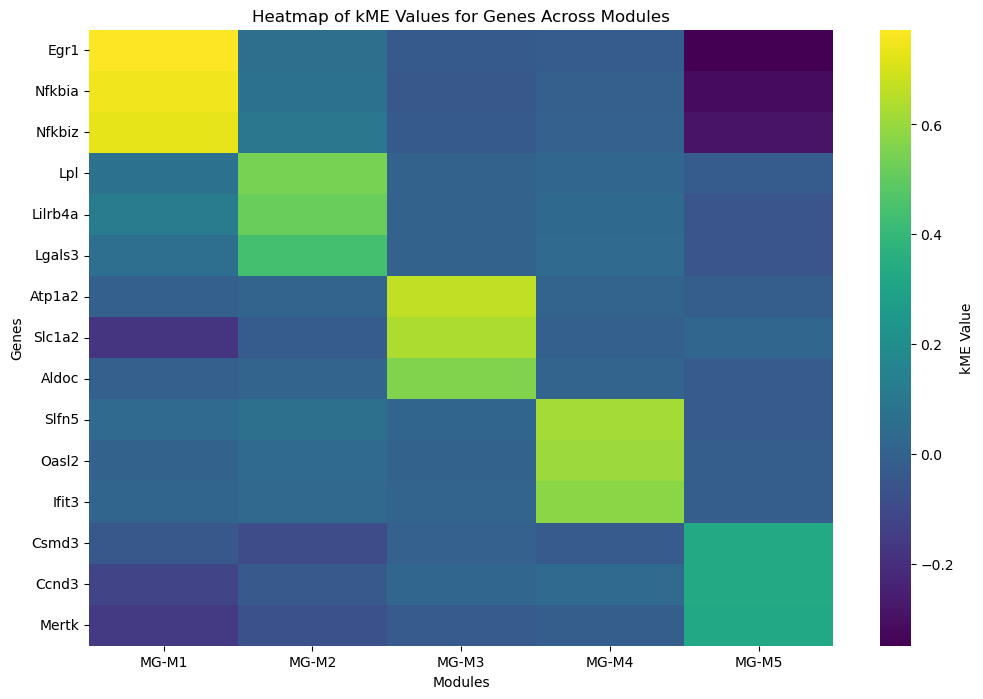

In [27]:
# Map gene IDs to gene symbols
gene_symbol_mapping = gene_names_df["gene_symbol"].to_dict()
top_genes_df["gene_symbol"] = top_genes_df["gene_name"].map(gene_symbol_mapping)

# Prepare the data for the heatmap
heatmap_data = top_genes_df.set_index("gene_symbol")[[f"kME_{module}" for module in top_genes_df["module"].unique()]]
heatmap_data.columns = [col.replace("kME_", "") for col in heatmap_data.columns]  # Simplify column names

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap="viridis",
    annot=False,
    cbar_kws={"label": "kME Value"}
)

# Set axis labels and title
plt.xlabel("Modules")
plt.ylabel("Genes")
plt.title("Heatmap of kME Values for Genes Across Modules")

plt.show()

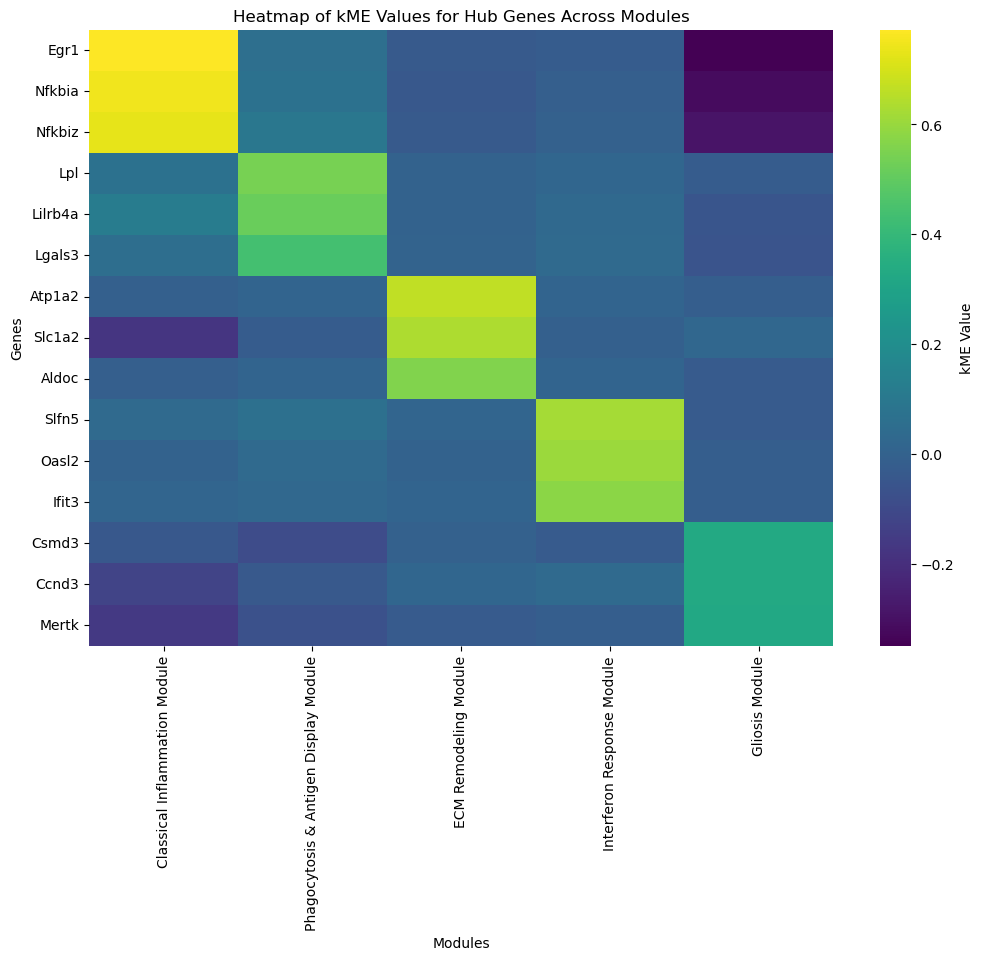

In [28]:
# Map gene IDs to gene symbols
gene_symbol_mapping = gene_names_df["gene_symbol"].to_dict()
top_genes_df["gene_symbol"] = top_genes_df["gene_name"].map(gene_symbol_mapping)

# Define a dictionary with old module names as keys and new module names as values
module_name_mapping = {
    "MG-M1": "Classical Inflammation Module",
    "MG-M2": "Phagocytosis & Antigen Display Module",
    "MG-M3": "ECM Remodeling Module",
    "MG-M4": "Interferon Response Module",
    "MG-M5": "Gliosis Module"
}

# Prepare the data for the heatmap
heatmap_data = top_genes_df.set_index("gene_symbol")[[f"kME_{module}" for module in top_genes_df["module"].unique()]]
heatmap_data.columns = [
    module_name_mapping.get(col.replace("kME_", ""), col.replace("kME_", ""))
    for col in heatmap_data.columns
]

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap="viridis",
    annot=False,
    cbar_kws={"label": "kME Value"}
)

# Set axis labels and title
plt.xlabel("Modules")
plt.ylabel("Genes")
plt.title("Heatmap of kME Values for Hub Genes Across Modules")

plt.show()


### Heatmap: ME across clusters

In [29]:
# Loading Module Eigengenes dataframe
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs")
MEs_df = pd.read_csv(base_path / f"WMB-10Xv3-{select_region}-raw-mc-wgcna-MEs.csv", index_col="Unnamed: 0")
MEs_df = MEs_df.drop(columns=["grey"])
MEs_df.head()

,blue,green,yellow,turquoise,brown
TGGATCAGTAACACCT-478_A02-0,3.520289,-0.434925,-1.310789,1.821404,0.717890
TCACTCGCAAGTTCGT-215_C01-0,-0.486307,-1.138845,-0.099216,-8.427007,-0.556104
GAGTGAGTCCTTATCA-472_B05-0,-3.545015,0.821186,-1.042361,11.035446,5.529251
CACGGGTTCATTTCCA-216_D01-0,2.866931,-1.964552,0.176167,-7.483160,-0.035609
TTTCACATCCGCACTT-171_C01-0,-1.317700,-2.456663,-0.528557,2.435767,1.356410


In [34]:
module_color_mapping = {
    "turquoise": "Classical Inflammation Module",
    "brown": "Phagocytosis & Antigen Display Module",
    "green": "ECM Remodeling Module",
    "yellow": "Interferon Response Module",
    "blue": "Gliosis Module"
}

# Replace column names of MEs_df based on the given dictionary
MEs_df.rename(columns=module_color_mapping, inplace=True)

# Display the updated DataFrame
MEs_df.head()

,Gliosis Module,ECM Remodeling Module,Interferon Response Module,Classical Inflammation Module,Phagocytosis & Antigen Display Module
TGGATCAGTAACACCT-478_A02-0,3.520289,-0.434925,-1.310789,1.821404,0.717890
TCACTCGCAAGTTCGT-215_C01-0,-0.486307,-1.138845,-0.099216,-8.427007,-0.556104
GAGTGAGTCCTTATCA-472_B05-0,-3.545015,0.821186,-1.042361,11.035446,5.529251
CACGGGTTCATTTCCA-216_D01-0,2.866931,-1.964552,0.176167,-7.483160,-0.035609
TTTCACATCCGCACTT-171_C01-0,-1.317700,-2.456663,-0.528557,2.435767,1.356410


In [30]:
def plot_module_eigengenes_by_cluster(adata, MEs_df, group_by="leiden", agg_func="mean"):
    """
    Plots the average or median of module eigengene values across clusters as a heatmap.

    Parameters:
    - adata: AnnData object
    - MEs_df: DataFrame of module eigengenes, indexed by cell barcodes
    - group_by: Column in adata.obs that defines cluster or group labels
    - agg_func: Aggregation function to use: 'mean' or 'median'
    """

    if agg_func not in ["mean", "median"]:
        raise ValueError("agg_func must be 'mean' or 'median'")

    # Ensure MEs_df index matches adata.obs
    MEs_df = MEs_df.copy()
    if not MEs_df.index.equals(adata.obs_names):
        MEs_df = MEs_df.loc[adata.obs_names]

    # Add cluster information
    MEs_df["cluster"] = adata.obs[group_by].values

    # Aggregate eigengene values by cluster
    if agg_func == "mean":
        agg_df = MEs_df.groupby("cluster").mean()
    else:  # median
        agg_df = MEs_df.groupby("cluster").median()

    # Drop the 'cluster' column if it exists in the result (shouldn’t but just in case)
    agg_df = agg_df.drop(columns=["cluster"], errors="ignore")

    # Reorder columns (clusters) if categorical
    if hasattr(adata.obs[group_by], "cat"):
        cluster_order = adata.obs[group_by].cat.categories
        agg_df = agg_df.loc[cluster_order]

    # Plot the heatmap
    fig_width = max(8, agg_df.shape[0] * 1.2)
    fig_height = max(6, agg_df.shape[1] * 0.5)

    plt.figure(figsize=(fig_width, fig_height))
    sns.heatmap(
        agg_df.T,  # modules on y-axis, clusters on x-axis
        cmap="vlag",
        yticklabels=True,
        xticklabels=True,
        cbar_kws={"label": f"{agg_func.capitalize()} Module Eigengene Value"}
    )

    plt.xlabel("Cluster")
    plt.ylabel("Module")
    plt.title(f"{agg_func.capitalize()} Module Eigengene Expression Across Clusters")
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_44912/1153218093.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_df = MEs_df.groupby("cluster").mean()


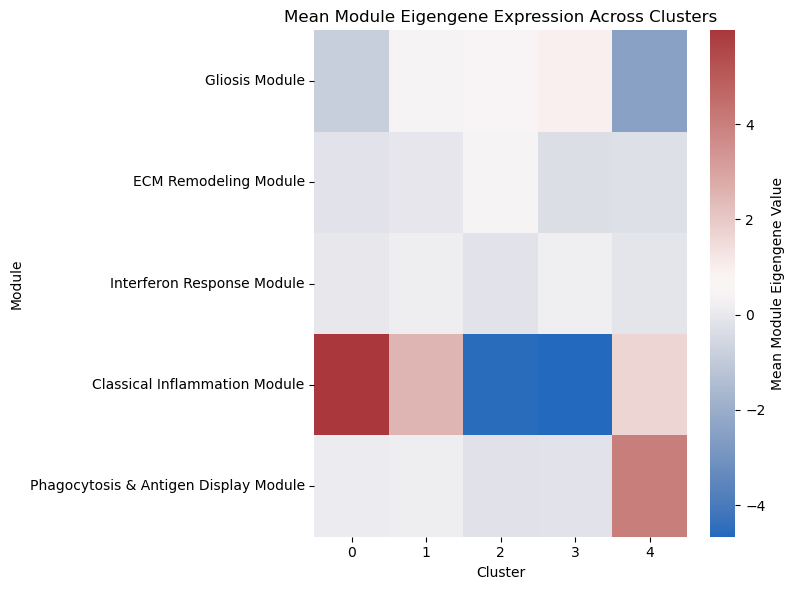

In [35]:
plot_module_eigengenes_by_cluster(
    adata=adata,
    MEs_df=MEs_df,  # Must be indexed by cell barcodes
    group_by=leiden_key,
    agg_func="mean"  # "mean" or "median"
)

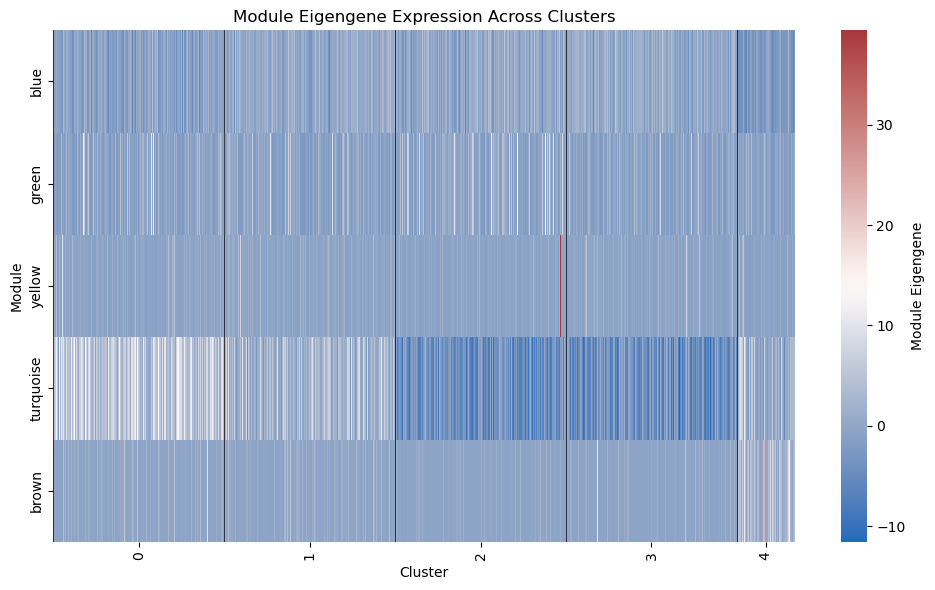

In [41]:
# Match cells and add cluster info
MEs_df["cluster"] = adata.uns[leiden_key]

# Compute group sizes
group_sizes = adata.obs[group_by].value_counts()
max_group_size = group_sizes.max() if len(group_sizes) > 0 else 1
scaling_factors = group_sizes / max_group_size
adata.obs["scaled_group"] = adata.obs[group_by].map(scaling_factors)

# Downsample cells to balance the heatmap
max_cells_per_group = 500
downsampled_indices = []
for group, size in group_sizes.items():
    group_indices = adata.obs[adata.obs[group_by] == group].index.to_list()
    if size > max_cells_per_group:
        sampled_indices = np.random.choice(group_indices, max_cells_per_group, replace=False)
    else:
        sampled_indices = group_indices
    downsampled_indices.extend(sampled_indices)

# Subset AnnData and eigengene dataframe
adata_downsampled = adata[downsampled_indices].copy()
MEs_downsampled = MEs_df.loc[downsampled_indices].copy()

# Sort by cluster for visual clarity
MEs_downsampled["cluster"] = adata_downsampled.obs[group_by].values
MEs_downsampled_sorted = MEs_downsampled.sort_values("cluster")
clusters_sorted = MEs_downsampled_sorted["cluster"]
eigengenes_sorted = MEs_downsampled_sorted.drop(columns="cluster")

# Plot as a heatmap
fig_width = max(10, len(clusters_sorted.unique()) * 2)
fig_height = max(6, len(eigengenes_sorted.columns) * 0.5)

plt.figure(figsize=(fig_width, fig_height))
sns.heatmap(
    eigengenes_sorted.T,
    cmap="vlag",
    yticklabels=True,
    xticklabels=False,
    cbar_kws={"label": "Module Eigengene"}
)

# Mark cluster boundaries
current_pos = 0
xticks = []
xlabels = []
for cluster in clusters_sorted.unique():
    count = (clusters_sorted == cluster).sum()
    xticks.append(current_pos + count // 2)
    xlabels.append(cluster)
    plt.axvline(current_pos, color='black', linewidth=0.5)
    current_pos += count

plt.xticks(xticks, xlabels, rotation=90)
plt.xlabel("Cluster")
plt.ylabel("Module")
plt.title("Module Eigengene Expression Across Clusters")
plt.tight_layout()
plt.show()


In [42]:
top_genes_df

,gene_name,module,color,kME_MG-M1,kME_grey,kME_MG-M2,kME_MG-M3,kME_MG-M4,kME_MG-M5,gene_symbol
0,ENSMUSG00000038418,MG-M1,turquoise,0.772310,0.063035,0.054245,-0.034519,-0.026892,-0.348611,Egr1
1,ENSMUSG00000021025,MG-M1,turquoise,0.747866,0.002690,0.069530,-0.046087,-0.013457,-0.313880,Nfkbia
2,ENSMUSG00000035356,MG-M1,turquoise,0.732437,0.023227,0.095436,-0.033552,-0.004144,-0.288948,Nfkbiz
3,ENSMUSG00000015568,MG-M2,brown,0.067394,0.009954,0.541998,-0.002288,0.017932,-0.027402,Lpl
4,ENSMUSG00000112148,MG-M2,brown,0.119674,0.019395,0.517916,-0.001351,0.030454,-0.055215,Lilrb4a
5,ENSMUSG00000050335,MG-M2,brown,0.050375,0.022079,0.438105,0.001724,0.034987,-0.056614,Lgals3
6,ENSMUSG00000007097,MG-M3,green,-0.009486,0.236036,0.007770,0.665706,0.006892,-0.016427,Atp1a2
7,ENSMUSG00000005089,MG-M3,green,-0.174240,0.278792,-0.027461,0.632778,-0.011341,0.020034,Slc1a2
8,ENSMUSG00000017390,MG-M3,green,-0.013471,0.199158,0.009662,0.561030,0.007734,-0.030248,Aldoc
9,ENSMUSG00000054404,MG-M4,yellow,0.035449,0.016711,0.061497,0.011578,0.622220,-0.031684,Slfn5
